In [52]:
# ============================================================
#   1. Imports
# ============================================================
import matplotlib.pyplot as plt
import torch
import importlib
import train_kan_mnist
importlib.reload(train_kan_mnist)
from train_kan_mnist import cfg, train_mnist, load_mnist, train_mnist_with_stats
from hyperparam_search import grid_search
import kan
importlib.reload(kan)
from kan import KAN, LogActivationLayer, PosNegActivationLayer    # In case you want direct access

In [53]:
# ============================================================
#   2. Configure Training
# ============================================================
# Modify configuration directly in the notebook if needed

cfg.max_epochs = 10           # how long to train
cfg.hidden_sizes = (10)  # architecture
cfg.lr = 1e-3                 # learning rate
cfg.patience = 3              # early stopping patience

cfg.normalize = True
cfg.flatten = True

print("Configuration:")
cfg.__dict__


Configuration:


{'max_epochs': 10,
 'hidden_sizes': 10,
 'lr': 0.001,
 'patience': 3,
 'normalize': True,
 'flatten': True}

Epoch 1/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 45.15s
Epoch 2/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 39.37s
Epoch 3/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 38.98s
Epoch 4/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 38.48s
Epoch 5/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 38.74s
Epoch 6/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 38.51s
Epoch 7/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 37.86s
Epoch 8/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 38.48s
Epoch 9/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 38.39s
Epoch 10/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 38.24s
Early stopping.

Final Val Loss: nan, Final Val Acc: 9.80%


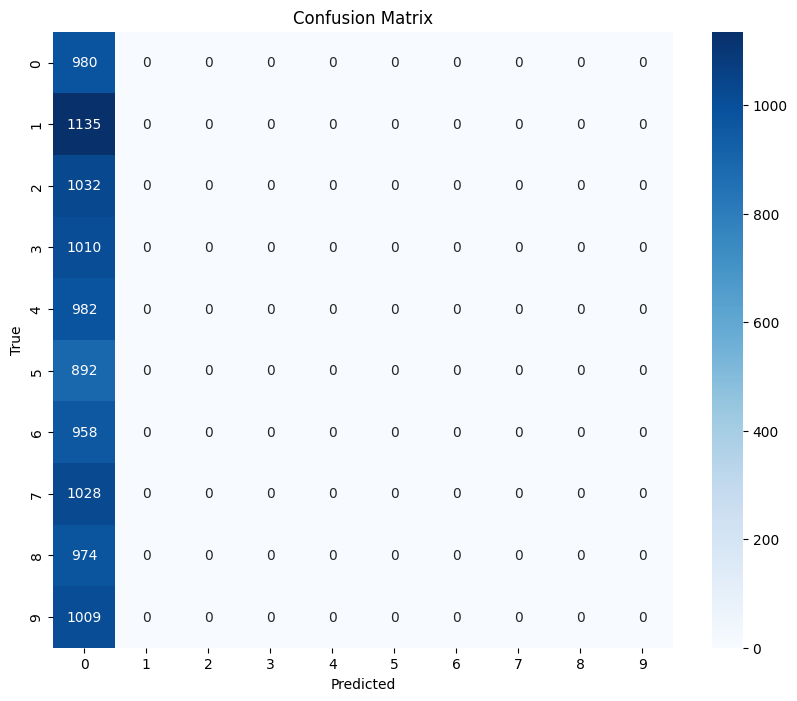

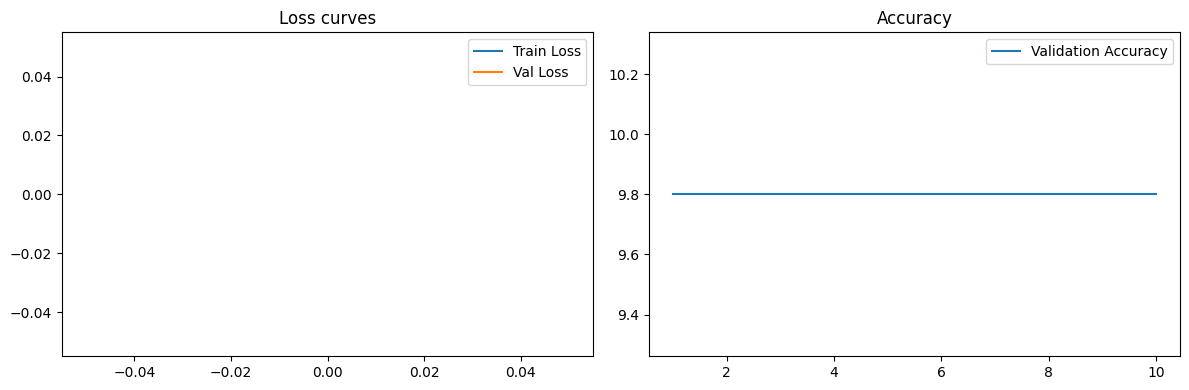

In [54]:
cfg.max_epochs = 10        # e.g. 10 epochs
cfg.hidden_sizes = [10]    # simple small network
cfg.patience = 10          # no early stop before 10, if you like

model = train_mnist(cfg, show_confusion=True)

In [50]:
# ============================================================
#   3. Basic Model Training WITH STATS + TRACE PER EPOCH
# ============================================================
cfg.max_epochs = 10        # e.g. 10 epochs
cfg.hidden_sizes = [10]    # simple small network
cfg.patience = 10          # no early stop before 10, if you like

# This will:
#  - print layer-wise min/max input/output after each epoch
#  - export a single-sample trace after each epoch
final_model = train_mnist_with_stats(
    cfg,
    show_confusion=True,
    sample_index_for_trace=0,   # which test sample to trace
)


Epoch 1/10 | Train Loss nan | Val Loss nan | Val Acc 9.80% | Time 34.78s
  Layer stats (min/max input & output):
    Layer 0: in [0.0, 1.0], out [nan, nan]
    Layer 1: in [2056.965561428612, 2071.3289077210443], out [nan, nan]


AttributeError: 'tuple' object has no attribute 'squeeze'

In [41]:

@torch.no_grad()
def plot_posneg_activation_for_detuning(layer,
                                        detn: float,
                                        detp: float,
                                        x_min: float = 0.0,
                                        x_max: float = 10.0,
                                        num_points: int = 500,
                                        gamma1: float = 1.0,
                                        gamma2: float = 1.0,
                                        device: str = "cpu"):
    """
    Visualize fp(det, x), fn(det, x) and f = gamma1*fp + gamma2*fn
    for a given detuning value `det` using the spline definitions
    inside `PosNegActivationLayer`.

    Assumes `layer` is an instance of PosNegActivationLayer
    with attributes:
        b_splines, mu_detuning, sigma_detuning,
        A_base, log_A_scale,
        clamp_w, _eval_bspline, _fp_core
    """

    layer = layer.to(device)

    # 1D input grid
    x = torch.linspace(x_min, x_max, num_points,
                       dtype=torch.float64, device=device)  # (N,)
    # Shape (N, 1, 1) to match layer._fp_core expectations
    x_exp = x.unsqueeze(1).unsqueeze(1)

    # Single detuning as a 1x1 "weight"
    w_n = torch.full((1, 1), detn, dtype=torch.float64, device=device)
    w_n_clamped = layer.clamp_w(w_n)
    w_n_norm = (w_n_clamped - layer.mu_detuning.to(device)) / layer.sigma_detuning.to(device)

    w_p = torch.full((1, 1), detp, dtype=torch.float64, device=device)
    w_p_clamped = layer.clamp_w(w_p)
    w_p_norm = (w_p_clamped - layer.mu_detuning.to(device)) / layer.sigma_detuning.to(device)
    # Evaluate spline coefficients b1,...,b8 at this detuning
    bn_vals = [
        layer._eval_bspline(w_n_norm, br.to(device), cf.to(device))
        for (br, cf) in layer.b_splines
    ]
    b1n, b2n, b3n, b4n, b5n, b6n, b7n, b8n = bn_vals

    bp_vals = [
        layer._eval_bspline(w_p_norm, br.to(device), cf.to(device))
        for (br, cf) in layer.b_splines
    ]
    b1p, b2p, b3p, b4p, b5p, b6p, b7p, b8p = bp_vals

    # Effective A (same as in your layer)
    A = layer.A.to(device)
    
    # Core fn(det, x)
    fn_core = layer._fp_core(x_exp, b1n, b2n, b3n, b4n, b5n, b6n, b7n, b8n)  # (N, 1, 1)
    fn_core = fn_core.squeeze()  # -> (N,)
    fn_val = A - fn_core

    # Core fp(det, x)
    fp_val = layer._fp_core(x_exp, b1p, b2p, b3p, b4p, b5p, b6p, b7p, b8p)  # (N, 1, 1)
    fp_val = fp_val.squeeze()  # -> (N,)

    # Full activation f = gamma1*fp + gamma2*fn
    f_val = gamma1 * fp_val + gamma2 * fn_val

    # ---- Plot ----
    x_np = x.cpu().numpy()
    fp_np = fp_val.cpu().numpy()
    fn_np = fn_val.cpu().numpy()
    f_np  = f_val.cpu().numpy()

    plt.figure()
    plt.plot(x_np, fp_np, label=f"fp(det={detp})")
    plt.plot(x_np, fn_np, label=f"fn(det={detn})")
    plt.plot(x_np, f_np,  label=f"f = {gamma1}·fp + {gamma2}·fn")
    plt.xlabel("x")
    plt.ylabel("activation")
    plt.title(f"PosNeg activation for detuning = {detn}, {detp}")
    plt.legend()
    plt.grid(True)
    plt.show()


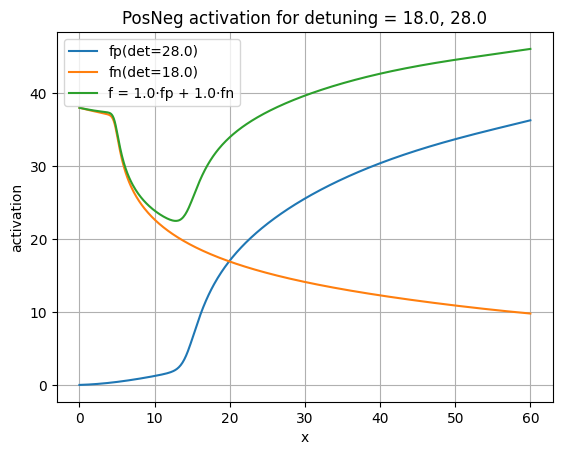

In [42]:
layer = kan.PosNegActivationLayer(in_count=1, out_count=1)

# Example: detuning 10, x ∈ [0, 10], gamma1 = gamma2 = 1
plot_posneg_activation_for_detuning(layer,
                                    detn=18.0,
                                    detp=28.0,
                                    x_min=0.0,
                                    x_max=60.0,
                                    gamma1=1.0,
                                    gamma2=1.0)


In [ ]:
# ============================================================
#   4. Hyperparameter Search
# ============================================================

param_grid = {
    "hidden_sizes": [
        (128, 64),
        (256, 128),
    ],
    "lr": [1e-3, 5e-4],
    "batch_size": [64, 128],
    "patience": [3, 5],
    "activation": [LogActivationLayer],
}

best_model, best_params, best_acc = grid_search(
    param_grid,
    max_trials=6     # keep small for testing; increase later
)

best_params


In [ ]:
# ============================================================
#   5. Train the Model
# ============================================================
cfg.hidden_sizes = best_params["hidden_sizes"]
cfg.lr = best_params["lr"]
cfg.batch_size = best_params["batch_size"]
cfg.patience = best_params["patience"]
cfg.activation_cls = best_params["activation"]

final_model = train_mnist(cfg, show_confusion=True)
final_model


In [ ]:
# ============================================================
#   4. Load MNIST Test Set for Analysis
# ============================================================
_, (x_test, y_test) = load_mnist(cfg)

print("Test set shape:", x_test.shape)


In [ ]:
# ============================================================
#   5. Manual Evaluation
# ============================================================
final_model.eval()
with torch.no_grad():
    logits = final_model(x_test)
    preds = logits.argmax(dim=1)

accuracy = (preds == y_test).float().mean().item() * 100
print(f"Manual Accuracy: {accuracy:.2f}%")


In [ ]:
# ============================================================
#   6. Export Single Sample Activation Trace
#       (For MATLAB or further analysis)
# ============================================================

sample = x_test[0].unsqueeze(0)

final_model.export_single_sample_trace(
    sample,
    filename="activation_trace_best_model_sample0.mat"
)

print("Exported trace for sample 0.")


In [ ]:
# ============================================================
#   7. Visualize First Misclassified Digit (optional)
# ============================================================
import matplotlib.pyplot as plt

misclassified = ((preds != y_test).nonzero(as_tuple=True)[0])

if len(misclassified) == 0:
    print("No misclassifications!")
else:
    idx = misclassified[0].item()
    true_label = y_test[idx].item()
    pred_label = preds[idx].item()

    print(f"Misclassified index: {idx}, True: {true_label}, Pred: {pred_label}")

    img = x_test[idx].view(28, 28).cpu().numpy()
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")
    plt.show()


In [ ]:
# ============================================================
#   8. Save the trained model manually (optional)
# ============================================================
torch.save(final_model.state_dict(), "kan_mnist_trained.pt")
print("Model saved.")
